# EDA 13.1: Delivery Time Analysis

This notebook analyzes delivery duration, regional delivery speed, and whether slower delivery is associated with lower customer ratings or higher return rates. It also previews leakage-safe historical delivery aggregates for forecasting or explainability.

## 1. Setup and File Discovery

Locate the required CSV files under the current working directory. Missing files generate warnings and the notebook continues where possible.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 240)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['shipments.csv', 'orders.csv', 'geography.csv', 'reviews.csv', 'returns.csv']
REQUIRED = set(FILES)

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame([
    {'file': name, 'required': name in REQUIRED, 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

for name, path in selected_paths.items():
    if path is None and name in REQUIRED:
        warnings.warn(f'Required file missing: {name}. The notebook will continue where possible.')

,file,required,found,path
0,shipments.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\sh...
1,orders.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
2,geography.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\ge...
3,reviews.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\re...
4,returns.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\re...


## 2. Load Shipments, Orders, Geography, Reviews, and Returns

Load all available files safely with pandas and display schema context.

In [2]:
def load_csv_safe(path):
    if path is None:
        return None
    try:
        return pd.read_csv(path)
    except Exception as exc:
        warnings.warn(f'Failed to load {path}: {exc}')
        return None

data = {name.replace('.csv', ''): load_csv_safe(path) for name, path in selected_paths.items()}
shipments = data.get('shipments')
orders = data.get('orders')
geography = data.get('geography')
reviews = data.get('reviews')
returns = data.get('returns')

schema_rows = []
for name, df in data.items():
    schema_rows.append({
        'dataset': name,
        'loaded': df is not None,
        'rows': None if df is None else len(df),
        'columns': None if df is None else ', '.join(map(str, df.columns[:20]))
    })
display(pd.DataFrame(schema_rows))

,dataset,loaded,rows,columns
0,shipments,True,566067,"order_id, ship_date, delivery_date, shipping_fee"
1,orders,True,646945,"order_id, order_date, customer_id, zip, order_..."
2,geography,True,39948,"zip, city, region, district"
3,reviews,True,113551,"review_id, order_id, product_id, customer_id, ..."
4,returns,True,39939,"return_id, order_id, product_id, return_date, ..."


## 3. Identify Shipment, Order, Geography, Review, Return, and Date Columns

Use tolerant matching for likely naming variations. Delivery duration is computed from the available date fields where needed.

In [3]:
def normalized_map(columns):
    return {normalize_name(c): c for c in columns}

def find_column(columns, candidates, contains=False):
    nmap = normalized_map(columns)
    normalized_candidates = [normalize_name(c) for c in candidates]
    for cand in normalized_candidates:
        if cand in nmap:
            return nmap[cand]
    if contains:
        for cand in normalized_candidates:
            for ncol, raw in nmap.items():
                if cand in ncol:
                    return raw
    return None

shipment_cols = {}
if shipments is not None:
    shipment_cols = {
        'shipment_id': find_column(shipments.columns, ['shipment_id', 'shipping_id', 'id'], contains=True),
        'order_id': find_column(shipments.columns, ['order_id']),
        'customer_id': find_column(shipments.columns, ['customer_id', 'user_id'], contains=True),
        'ship_date': find_column(shipments.columns, ['ship_date', 'shipment_date', 'shipped_date', 'dispatch_date'], contains=True),
        'delivery_date': find_column(shipments.columns, ['delivery_date', 'delivered_date', 'arrival_date'], contains=True),
        'estimated_delivery_date': find_column(shipments.columns, ['estimated_delivery_date', 'eta', 'estimated_date'], contains=True),
        'delivery_status': find_column(shipments.columns, ['delivery_status', 'shipment_status', 'status'], contains=True),
        'zip': find_column(shipments.columns, ['zip', 'postal_code', 'zipcode'], contains=True),
        'city': find_column(shipments.columns, ['city']),
        'region': find_column(shipments.columns, ['region', 'state', 'province']),
    }

orders_cols = {}
if orders is not None:
    orders_cols = {
        'order_id': find_column(orders.columns, ['order_id']),
        'customer_id': find_column(orders.columns, ['customer_id', 'user_id'], contains=True),
        'order_date': find_column(orders.columns, ['order_date', 'date', 'created_at'], contains=True),
        'order_status': find_column(orders.columns, ['order_status', 'status'], contains=True),
        'zip': find_column(orders.columns, ['zip', 'postal_code', 'zipcode'], contains=True),
    }

geography_cols = {}
if geography is not None:
    geography_cols = {
        'zip': find_column(geography.columns, ['zip', 'postal_code', 'zipcode'], contains=True),
        'city': find_column(geography.columns, ['city']),
        'region': find_column(geography.columns, ['region', 'state', 'province']),
        'district': find_column(geography.columns, ['district']),
    }

review_cols = {}
if reviews is not None:
    review_cols = {
        'order_id': find_column(reviews.columns, ['order_id']),
        'customer_id': find_column(reviews.columns, ['customer_id', 'user_id'], contains=True),
        'review_date': find_column(reviews.columns, ['review_date', 'date'], contains=True),
        'rating': find_column(reviews.columns, ['rating', 'score', 'stars'], contains=True),
    }

return_cols = {}
if returns is not None:
    return_cols = {
        'order_id': find_column(returns.columns, ['order_id']),
        'return_date': find_column(returns.columns, ['return_date', 'date'], contains=True),
        'return_quantity': find_column(returns.columns, ['return_quantity', 'quantity_returned', 'qty'], contains=True),
        'refund_amount': find_column(returns.columns, ['refund_amount', 'refund', 'refund_value'], contains=True),
    }

identified = pd.DataFrame({
    'shipments': pd.Series(shipment_cols),
    'orders': pd.Series(orders_cols),
    'geography': pd.Series(geography_cols),
    'reviews': pd.Series(review_cols),
    'returns': pd.Series(return_cols),
})
display(identified)

,shipments,orders,geography,reviews,returns
city,None,NaN,city,NaN,NaN
customer_id,None,customer_id,NaN,customer_id,NaN
delivery_date,delivery_date,NaN,NaN,NaN,NaN
delivery_status,None,NaN,NaN,NaN,NaN
district,NaN,NaN,district,NaN,NaN
estimated_delivery_date,None,NaN,NaN,NaN,NaN
order_date,NaN,order_date,NaN,NaN,NaN
order_id,order_id,order_id,NaN,order_id,order_id
order_status,NaN,order_status,NaN,NaN,NaN
rating,NaN,NaN,NaN,rating,NaN


## 4. Shipment Data Quality Checks

Standardize the shipment date fields and inspect missingness, duplicates, and invalid date sequences.

In [4]:
delivery_warnings = []
shipments_clean = None

if shipments is not None:
    shipments_clean = shipments.copy()
    shipments_clean['order_id_std'] = shipments_clean[shipment_cols['order_id']] if shipment_cols.get('order_id') else pd.NA
    shipments_clean['customer_id_std'] = shipments_clean[shipment_cols['customer_id']] if shipment_cols.get('customer_id') else pd.NA
    shipments_clean['ship_date_std'] = pd.to_datetime(shipments_clean[shipment_cols['ship_date']], errors='coerce') if shipment_cols.get('ship_date') else pd.NaT
    shipments_clean['delivery_date_std'] = pd.to_datetime(shipments_clean[shipment_cols['delivery_date']], errors='coerce') if shipment_cols.get('delivery_date') else pd.NaT
    shipments_clean['estimated_delivery_date_std'] = pd.to_datetime(shipments_clean[shipment_cols['estimated_delivery_date']], errors='coerce') if shipment_cols.get('estimated_delivery_date') else pd.NaT
    shipments_clean['delivery_status_std'] = shipments_clean[shipment_cols['delivery_status']].astype(str).str.strip().str.lower() if shipment_cols.get('delivery_status') else pd.NA
    shipments_clean['zip_std'] = shipments_clean[shipment_cols['zip']] if shipment_cols.get('zip') else pd.NA

    invalid_ship_delivery = (
        shipments_clean['ship_date_std'].notna()
        & shipments_clean['delivery_date_std'].notna()
        & (shipments_clean['delivery_date_std'] < shipments_clean['ship_date_std'])
    )

    duplicate_order_records = int(shipments_clean.duplicated(subset=['order_id_std']).sum())
    quality = pd.DataFrame([{
        'shipment_rows': len(shipments_clean),
        'shipment_date_min': shipments_clean['ship_date_std'].min(),
        'shipment_date_max': shipments_clean['ship_date_std'].max(),
        'delivery_date_min': shipments_clean['delivery_date_std'].min(),
        'delivery_date_max': shipments_clean['delivery_date_std'].max(),
        'missing_order_ids': int(shipments_clean['order_id_std'].isna().sum()),
        'missing_shipment_dates': int(shipments_clean['ship_date_std'].isna().sum()),
        'missing_delivery_dates': int(shipments_clean['delivery_date_std'].isna().sum()),
        'duplicate_order_records': duplicate_order_records,
        'invalid_ship_delivery_sequence': int(invalid_ship_delivery.sum()),
    }])
    display(quality)

    if quality.loc[0, 'missing_delivery_dates'] > 0:
        delivery_warnings.append(f"{quality.loc[0, 'missing_delivery_dates']} shipment rows have missing delivery dates")
    if quality.loc[0, 'invalid_ship_delivery_sequence'] > 0:
        delivery_warnings.append(f"{quality.loc[0, 'invalid_ship_delivery_sequence']} shipment rows have delivery_date before ship_date")
else:
    warnings.warn('shipments.csv not available.')

,shipment_rows,shipment_date_min,shipment_date_max,delivery_date_min,delivery_date_max,missing_order_ids,missing_shipment_dates,missing_delivery_dates,duplicate_order_records,invalid_ship_delivery_sequence
0,566067,2012-07-04,2022-12-29,2012-07-06,2022-12-31,0,0,0,0,0


## 5. Build Delivery Dataset

Join shipments to orders and geography, compute delivery durations, and define a late-delivery flag. Since no estimated delivery date is present here, late delivery is defined from the data distribution.

In [5]:
orders_clean = None
geography_clean = None
delivery_df = pd.DataFrame()

if orders is not None:
    orders_clean = orders.copy()
    orders_clean['order_id_std'] = orders_clean[orders_cols['order_id']] if orders_cols.get('order_id') else pd.NA
    orders_clean['customer_id_std'] = orders_clean[orders_cols['customer_id']] if orders_cols.get('customer_id') else pd.NA
    orders_clean['order_date_std'] = pd.to_datetime(orders_clean[orders_cols['order_date']], errors='coerce') if orders_cols.get('order_date') else pd.NaT
    orders_clean['order_status_std'] = orders_clean[orders_cols['order_status']].astype(str).str.strip().str.lower() if orders_cols.get('order_status') else pd.NA
    orders_clean['zip_std'] = orders_clean[orders_cols['zip']] if orders_cols.get('zip') else pd.NA

if geography is not None:
    geography_clean = geography.copy()
    geography_clean['zip_std'] = geography_clean[geography_cols['zip']] if geography_cols.get('zip') else pd.NA
    geography_clean['city_std'] = geography_clean[geography_cols['city']] if geography_cols.get('city') else pd.NA
    geography_clean['region_std'] = geography_clean[geography_cols['region']] if geography_cols.get('region') else pd.NA
    geography_clean['district_std'] = geography_clean[geography_cols['district']] if geography_cols.get('district') else pd.NA
    geography_clean = geography_clean.drop_duplicates(subset=['zip_std'])

if shipments_clean is not None:
    delivery_df = shipments_clean.copy()
    if orders_clean is not None:
        order_keep = ['order_id_std', 'customer_id_std', 'order_date_std', 'order_status_std', 'zip_std']
        delivery_df = delivery_df.merge(orders_clean[order_keep], on='order_id_std', how='left', indicator='order_merge')
    else:
        delivery_df['order_merge'] = 'left_only'

    if geography_clean is not None:
        if 'zip_std_x' in delivery_df.columns:
            delivery_df['zip_join'] = delivery_df['zip_std_x'].fillna(delivery_df.get('zip_std_y'))
        elif 'zip_std' in delivery_df.columns:
            delivery_df['zip_join'] = delivery_df['zip_std']
        else:
            delivery_df['zip_join'] = pd.NA
        geo_keep = ['zip_std', 'city_std', 'region_std', 'district_std']
        delivery_df = delivery_df.merge(geography_clean[geo_keep], left_on='zip_join', right_on='zip_std', how='left', indicator='geo_merge')
    else:
        delivery_df['geo_merge'] = 'left_only'

    delivery_df['delivery_days_from_ship'] = (delivery_df['delivery_date_std'] - delivery_df['ship_date_std']).dt.days
    delivery_df['delivery_days_from_order'] = (delivery_df['delivery_date_std'] - delivery_df['order_date_std']).dt.days
    delivery_df['delivery_delay_days'] = (delivery_df['delivery_date_std'] - delivery_df['estimated_delivery_date_std']).dt.days if shipment_cols.get('estimated_delivery_date') else np.nan

    duration_base = 'delivery_days_from_ship'
    if delivery_df['delivery_days_from_ship'].notna().sum() == 0 and delivery_df['delivery_days_from_order'].notna().sum() > 0:
        duration_base = 'delivery_days_from_order'

    if shipment_cols.get('estimated_delivery_date') and delivery_df['estimated_delivery_date_std'].notna().any():
        delivery_df['is_late_delivery'] = delivery_df['delivery_delay_days'] > 0
        late_definition = 'Late delivery uses delivered_date > estimated_delivery_date.'
    else:
        late_threshold = delivery_df[duration_base].dropna().quantile(0.75)
        delivery_df['is_late_delivery'] = delivery_df[duration_base] > late_threshold
        late_definition = f'Late delivery uses {duration_base} above the 75th percentile ({late_threshold:.2f} days) because no estimated delivery date is available.'

    display(pd.DataFrame([{'delivery_duration_used': duration_base, 'late_definition': late_definition}]))

    join_quality = pd.DataFrame([{
        'shipments_matched_to_orders': int((delivery_df['order_merge'] == 'both').sum()) if 'order_merge' in delivery_df.columns else 0,
        'shipments_unmatched_to_orders': int((delivery_df['order_merge'] == 'left_only').sum()) if 'order_merge' in delivery_df.columns else len(delivery_df),
        'rows_matched_to_geography': int((delivery_df['geo_merge'] == 'both').sum()) if 'geo_merge' in delivery_df.columns else 0,
        'rows_unmatched_to_geography': int((delivery_df['geo_merge'] == 'left_only').sum()) if 'geo_merge' in delivery_df.columns else len(delivery_df),
    }])
    display(join_quality)
    if join_quality.loc[0, 'shipments_unmatched_to_orders'] > 0:
        delivery_warnings.append(f"{join_quality.loc[0, 'shipments_unmatched_to_orders']} shipments did not match orders")
    if join_quality.loc[0, 'rows_unmatched_to_geography'] > 0:
        delivery_warnings.append(f"{join_quality.loc[0, 'rows_unmatched_to_geography']} shipment rows did not match geography")

C:\Users\ACER\AppData\Local\Temp\ipykernel_15616\2546433415.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  delivery_df['zip_join'] = delivery_df['zip_std_x'].fillna(delivery_df.get('zip_std_y'))


,delivery_duration_used,late_definition
0,delivery_days_from_ship,Late delivery uses delivery_days_from_ship abo...


,shipments_matched_to_orders,shipments_unmatched_to_orders,rows_matched_to_geography,rows_unmatched_to_geography
0,566067,0,566067,0


## 6. Delivery Duration Distribution

Summarize the delivery duration distribution and flag unusually long or invalid durations.

,average_delivery_days,median_delivery_days,std_delivery_days,p25_delivery_days,p75_delivery_days,p90_delivery_days,p95_delivery_days,min_delivery_days,max_delivery_days,late_delivery_ratio,negative_delivery_days
0,4.4992,4.0000,1.7070,3.0000,6.0000,7.0000,7.0000,2,7,0.1663,0


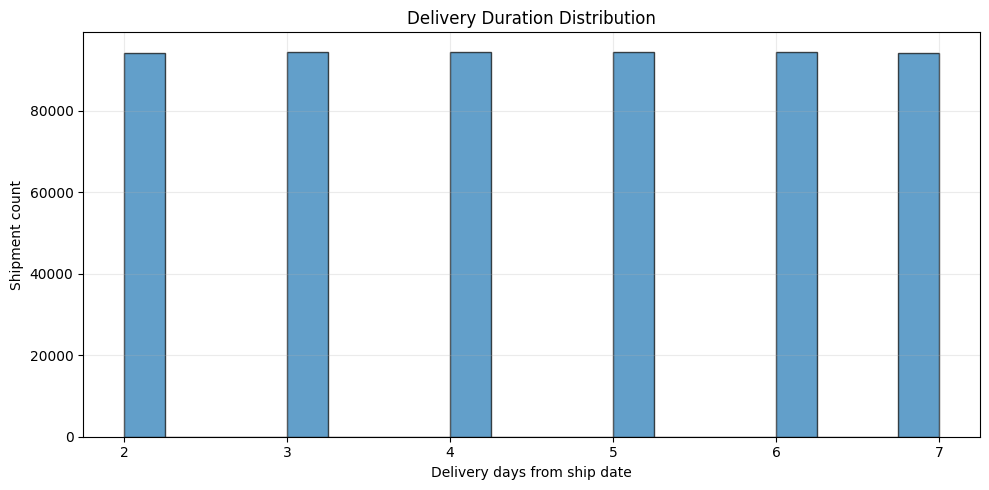

,order_id_std,ship_date_std,delivery_date_std,delivery_days_from_ship
4,6,2012-07-09,2012-07-16,7
14,20,2012-07-07,2012-07-14,7
18,25,2012-07-06,2012-07-13,7
32,45,2012-07-05,2012-07-12,7
42,62,2012-07-06,2012-07-13,7
45,67,2012-07-06,2012-07-13,7
46,68,2012-07-06,2012-07-13,7
55,81,2012-07-05,2012-07-12,7
56,82,2012-07-04,2012-07-11,7
68,95,2012-07-06,2012-07-13,7


In [6]:
duration_summary = pd.DataFrame()

if not delivery_df.empty:
    duration_series = delivery_df['delivery_days_from_ship']
    duration_summary = pd.DataFrame([{
        'average_delivery_days': duration_series.mean(),
        'median_delivery_days': duration_series.median(),
        'std_delivery_days': duration_series.std(),
        'p25_delivery_days': duration_series.quantile(0.25),
        'p75_delivery_days': duration_series.quantile(0.75),
        'p90_delivery_days': duration_series.quantile(0.90),
        'p95_delivery_days': duration_series.quantile(0.95),
        'min_delivery_days': duration_series.min(),
        'max_delivery_days': duration_series.max(),
        'late_delivery_ratio': delivery_df['is_late_delivery'].mean(),
        'negative_delivery_days': int(duration_series.dropna().lt(0).sum()),
    }])
    display(duration_summary)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(duration_series.dropna(), bins=20, color='tab:blue', edgecolor='black', alpha=0.7)
    ax.set_title('Delivery Duration Distribution')
    ax.set_xlabel('Delivery days from ship date')
    ax.set_ylabel('Shipment count')
    plt.tight_layout()
    plt.show()

    long_duration = delivery_df.loc[duration_series >= duration_series.quantile(0.95), ['order_id_std', 'ship_date_std', 'delivery_date_std', 'delivery_days_from_ship']].head(10)
    display(long_duration)
else:
    print('Delivery distribution cannot be computed because the delivery dataset is unavailable.')

## 7. Delivery Duration by Region

Summarize average, median, p90, and late-delivery ratio by region and identify the slowest and fastest regions.

,region_std,shipment_count,avg_delivery_days,median_delivery_days,p90_delivery_days,late_delivery_ratio
2,West,146923,4.4997,5.0000,7.0000,0.1656
1,East,257756,4.4993,4.0000,7.0000,0.1665
0,Central,161388,4.4986,4.0000,7.0000,0.1664


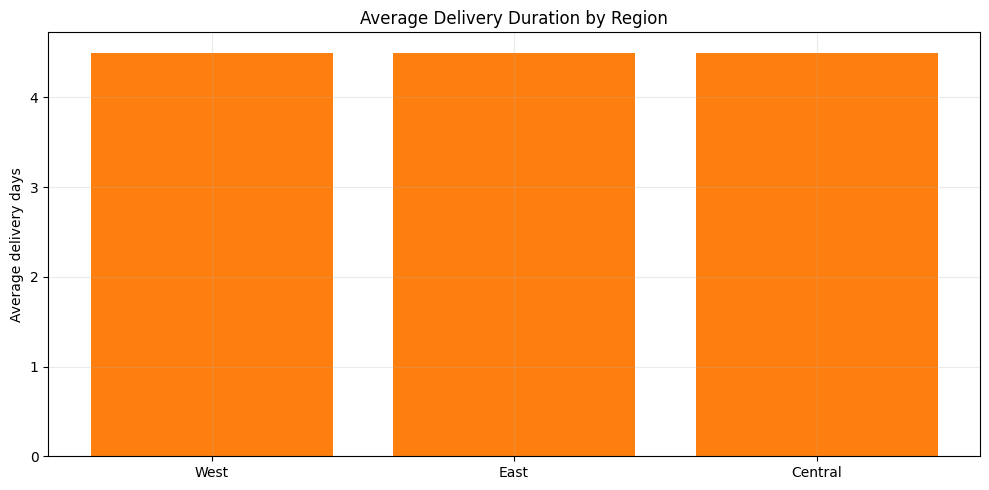

In [7]:
region_summary = pd.DataFrame()

if not delivery_df.empty and 'region_std' in delivery_df.columns and delivery_df['region_std'].notna().any():
    region_summary = delivery_df.groupby('region_std').agg(
        shipment_count=('order_id_std', 'size'),
        avg_delivery_days=('delivery_days_from_ship', 'mean'),
        median_delivery_days=('delivery_days_from_ship', 'median'),
        p90_delivery_days=('delivery_days_from_ship', lambda s: s.quantile(0.90)),
        late_delivery_ratio=('is_late_delivery', 'mean'),
    ).reset_index().sort_values('avg_delivery_days', ascending=False)
    display(region_summary)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(region_summary['region_std'].astype(str), region_summary['avg_delivery_days'], color='tab:orange')
    ax.set_title('Average Delivery Duration by Region')
    ax.set_ylabel('Average delivery days')
    plt.tight_layout()
    plt.show()
else:
    print('Region-level delivery analysis is unavailable because region could not be identified.')

## 8. Delivery Duration Over Time

Aggregate monthly delivery speed and late-delivery pressure to see whether logistics performance changes over time.

,month,shipment_count,avg_delivery_days,median_delivery_days,late_delivery_ratio
0,2012-07-01,3318,4.2791,4.0000,0.1326
1,2012-08-01,5348,4.5236,5.0000,0.1750
2,2012-09-01,4973,4.4796,4.0000,0.1577
3,2012-10-01,3982,4.5374,5.0000,0.1781
4,2012-11-01,3649,4.4925,4.0000,0.1688
5,2012-12-01,4909,4.4860,4.0000,0.1638
6,2013-01-01,4278,4.6498,5.0000,0.1882
7,2013-02-01,3576,4.5120,5.0000,0.1695
8,2013-03-01,5088,4.4703,4.0000,0.1639
9,2013-04-01,7667,4.4579,4.0000,0.1547


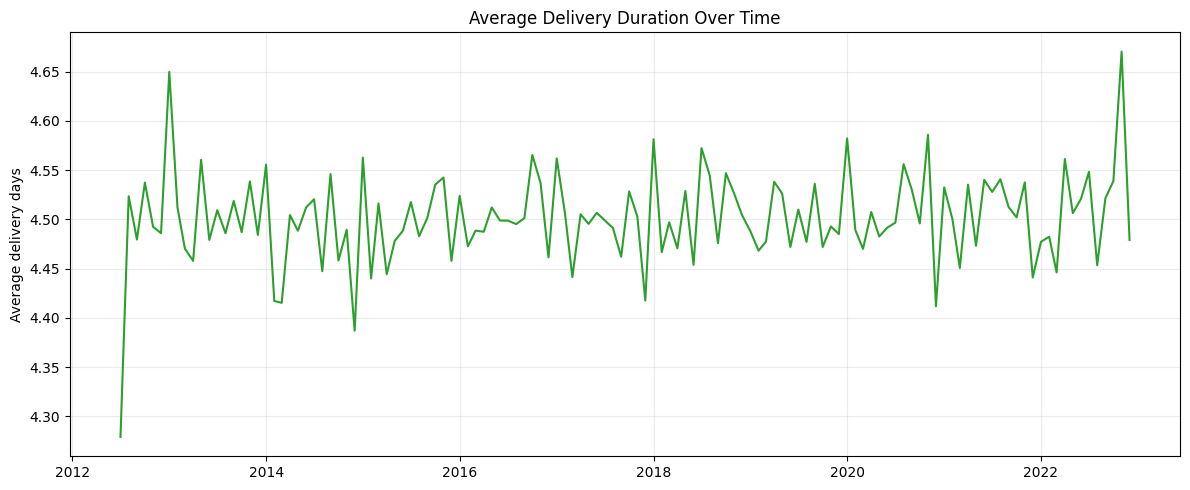

In [8]:
monthly_delivery = pd.DataFrame()

if not delivery_df.empty and delivery_df['delivery_date_std'].notna().any():
    temp = delivery_df.dropna(subset=['delivery_date_std']).copy()
    temp['month'] = temp['delivery_date_std'].dt.to_period('M').dt.to_timestamp()
    monthly_delivery = temp.groupby('month').agg(
        shipment_count=('order_id_std', 'size'),
        avg_delivery_days=('delivery_days_from_ship', 'mean'),
        median_delivery_days=('delivery_days_from_ship', 'median'),
        late_delivery_ratio=('is_late_delivery', 'mean'),
    ).reset_index()
    display(monthly_delivery.head(12))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly_delivery['month'], monthly_delivery['avg_delivery_days'], color='tab:green')
    ax.set_title('Average Delivery Duration Over Time')
    ax.set_ylabel('Average delivery days')
    plt.tight_layout()
    plt.show()
else:
    print('Monthly delivery trend cannot be built because delivery dates are unavailable.')

## 9. Delivery Duration vs Rating

Join reviews to delivery data by `order_id` and compare delivery duration across ratings and late/non-late deliveries.

Rating linkage uses exact order_id matching.


,is_late_delivery,order_count,avg_delivery_days,avg_rating
0,False,92820,4.0024,3.9370
1,True,18549,7.0000,3.9329


Correlation between delivery_days_from_ship and rating: -0.0062


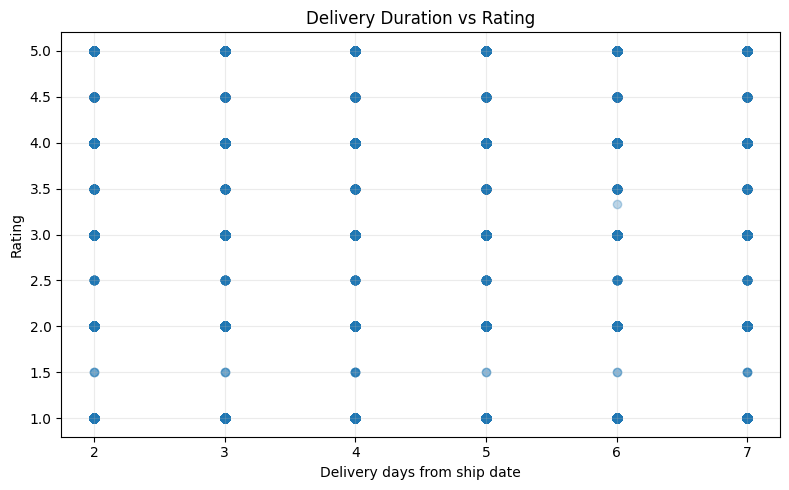

In [9]:
delivery_reviews = pd.DataFrame()
rating_link_note = ''

if not delivery_df.empty and reviews is not None and review_cols.get('order_id') and review_cols.get('rating'):
    reviews_clean = reviews.copy()
    reviews_clean['order_id_std'] = reviews_clean[review_cols['order_id']]
    reviews_clean['review_date_std'] = pd.to_datetime(reviews_clean[review_cols['review_date']], errors='coerce') if review_cols.get('review_date') else pd.NaT
    reviews_clean['rating_std'] = pd.to_numeric(reviews_clean[review_cols['rating']], errors='coerce')
    review_agg = reviews_clean.groupby('order_id_std').agg(
        rating=('rating_std', 'mean'),
        review_count=('rating_std', 'size'),
    ).reset_index()
    delivery_reviews = delivery_df.merge(review_agg, on='order_id_std', how='inner')
    rating_link_note = 'Rating linkage uses exact order_id matching.'
    print(rating_link_note)

    rating_group_summary = delivery_reviews.groupby('is_late_delivery').agg(
        order_count=('order_id_std', 'size'),
        avg_delivery_days=('delivery_days_from_ship', 'mean'),
        avg_rating=('rating', 'mean'),
    ).reset_index()
    display(rating_group_summary)
    print(f"Correlation between delivery_days_from_ship and rating: {delivery_reviews['delivery_days_from_ship'].corr(delivery_reviews['rating']):.4f}")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(delivery_reviews['delivery_days_from_ship'], delivery_reviews['rating'], alpha=0.3, color='tab:blue')
    ax.set_title('Delivery Duration vs Rating')
    ax.set_xlabel('Delivery days from ship date')
    ax.set_ylabel('Rating')
    plt.tight_layout()
    plt.show()
else:
    print('Delivery vs rating analysis is unavailable because reviews could not be linked reliably.')

## 10. Delivery Duration vs Return Rate

Join returns to delivery data by `order_id` and compare return rate for late and non-late deliveries.

C:\Users\ACER\AppData\Local\Temp\ipykernel_15616\555901434.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  delivery_returns['has_return'] = delivery_returns['has_return'].fillna(False)


,is_late_delivery,order_count,avg_delivery_days,return_rate,avg_refund_amount
0,False,471958,4.0005,0.0642,907.8423
1,True,94109,7.0000,0.0615,872.7653


,delivery_duration_bin,order_count,return_rate
0,fast,188640,0.0646
1,normal,94530,0.0631
2,slow,188788,0.0642
3,very_slow,94109,0.0615


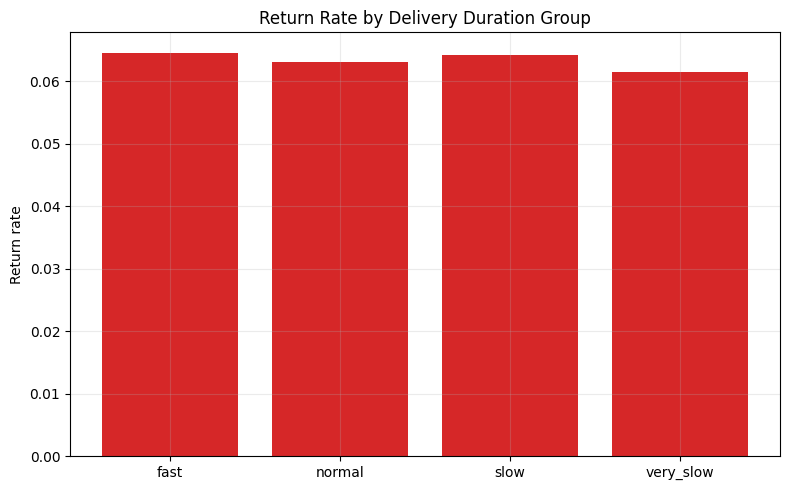

In [10]:
delivery_returns = pd.DataFrame()
return_bin_summary = pd.DataFrame()

if not delivery_df.empty and returns is not None and return_cols.get('order_id'):
    returns_clean = returns.copy()
    returns_clean['order_id_std'] = returns_clean[return_cols['order_id']]
    returns_clean['refund_amount_std'] = pd.to_numeric(returns_clean[return_cols['refund_amount']], errors='coerce') if return_cols.get('refund_amount') else np.nan
    return_agg = returns_clean.groupby('order_id_std').agg(
        return_count=('order_id_std', 'size'),
        refund_amount=('refund_amount_std', 'sum'),
    ).reset_index()
    return_agg['has_return'] = True
    delivery_returns = delivery_df.merge(return_agg, on='order_id_std', how='left')
    delivery_returns['has_return'] = delivery_returns['has_return'].fillna(False)
    delivery_returns['refund_amount'] = delivery_returns['refund_amount'].fillna(0)

    late_return_summary = delivery_returns.groupby('is_late_delivery').agg(
        order_count=('order_id_std', 'size'),
        avg_delivery_days=('delivery_days_from_ship', 'mean'),
        return_rate=('has_return', 'mean'),
        avg_refund_amount=('refund_amount', 'mean'),
    ).reset_index()
    display(late_return_summary)

    bins = [-np.inf, 3, 4, 6, np.inf]
    labels = ['fast', 'normal', 'slow', 'very_slow']
    delivery_returns['delivery_duration_bin'] = pd.cut(delivery_returns['delivery_days_from_ship'], bins=bins, labels=labels)
    return_bin_summary = delivery_returns.groupby('delivery_duration_bin', observed=False).agg(
        order_count=('order_id_std', 'size'),
        return_rate=('has_return', 'mean'),
    ).reset_index()
    display(return_bin_summary)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(return_bin_summary['delivery_duration_bin'].astype(str), return_bin_summary['return_rate'], color='tab:red')
    ax.set_title('Return Rate by Delivery Duration Group')
    ax.set_ylabel('Return rate')
    plt.tight_layout()
    plt.show()
else:
    print('Delivery vs return analysis is unavailable because returns could not be linked reliably.')

## 11. Delivery Speed Groups

Create interpretable speed groups and summarize counts, delivery days, ratings, and return rate where available.

In [11]:
speed_group_summary = pd.DataFrame()

if not delivery_df.empty:
    q25 = delivery_df['delivery_days_from_ship'].quantile(0.25)
    q75 = delivery_df['delivery_days_from_ship'].quantile(0.75)
    q90 = delivery_df['delivery_days_from_ship'].quantile(0.90)

    def speed_group(x):
        if pd.isna(x):
            return np.nan
        if x <= q25:
            return 'fast'
        if x <= q75:
            return 'normal'
        if x <= q90:
            return 'slow'
        return 'very_slow'

    base = delivery_df[['order_id_std', 'delivery_days_from_ship']].copy()
    base['delivery_speed_group'] = base['delivery_days_from_ship'].map(speed_group)
    if not delivery_reviews.empty:
        base = base.merge(delivery_reviews[['order_id_std', 'rating']], on='order_id_std', how='left')
    if not delivery_returns.empty:
        base = base.merge(delivery_returns[['order_id_std', 'has_return', 'refund_amount']].drop_duplicates('order_id_std'), on='order_id_std', how='left')
    else:
        base['has_return'] = np.nan
        base['refund_amount'] = np.nan

    speed_group_summary = base.groupby('delivery_speed_group', observed=False).agg(
        shipment_count=('order_id_std', 'size'),
        avg_delivery_days=('delivery_days_from_ship', 'mean'),
        avg_rating=('rating', 'mean'),
        return_rate=('has_return', 'mean'),
        avg_refund_amount=('refund_amount', 'mean'),
    ).reset_index()
    display(speed_group_summary)
else:
    print('Delivery speed groups could not be created.')

,delivery_speed_group,shipment_count,avg_delivery_days,avg_rating,return_rate,avg_refund_amount
0,fast,188640,2.5001,3.9479,0.0646,919.5240
1,normal,283318,4.9996,3.9297,0.0638,900.0644
2,slow,94109,7.0000,3.9329,0.0615,872.7653


## 12. Leakage-Safe Delivery Forecast Feature Preview

Create lagged historical delivery features only. Delivery features are usually medium-priority unless they show a strong relationship with ratings, returns, or Revenue.

In [12]:
feature_preview = pd.DataFrame()

if not monthly_delivery.empty:
    feat = monthly_delivery.sort_values('month').copy()
    feat['avg_delivery_days_lag'] = feat['avg_delivery_days'].shift(1)
    feat['late_delivery_ratio_lag'] = feat['late_delivery_ratio'].shift(1)
    feat['avg_delivery_days_roll_mean_3m'] = feat['avg_delivery_days'].shift(1).rolling(3, min_periods=1).mean()
    feat['late_delivery_ratio_roll_mean_3m'] = feat['late_delivery_ratio'].shift(1).rolling(3, min_periods=1).mean()
    feat['p90_delivery_days'] = feat['avg_delivery_days'].shift(0)  # placeholder overwritten below if needed

    p90_monthly = (
        delivery_df.dropna(subset=['delivery_date_std'])
        .assign(month=lambda d: d['delivery_date_std'].dt.to_period('M').dt.to_timestamp())
        .groupby('month')['delivery_days_from_ship']
        .quantile(0.90)
        .rename('p90_delivery_days')
        .reset_index()
    )
    feat = feat.drop(columns=['p90_delivery_days']).merge(p90_monthly, on='month', how='left')

    if not region_summary.empty:
        feat['region_late_delivery_pressure_lag'] = region_summary['late_delivery_ratio'].mean()
    else:
        feat['region_late_delivery_pressure_lag'] = np.nan

    preview_cols = [
        'month', 'shipment_count', 'avg_delivery_days', 'median_delivery_days',
        'late_delivery_ratio', 'p90_delivery_days', 'avg_delivery_days_lag',
        'late_delivery_ratio_lag', 'avg_delivery_days_roll_mean_3m',
        'late_delivery_ratio_roll_mean_3m', 'region_late_delivery_pressure_lag'
    ]
    feature_preview = feat[preview_cols].head(20)
    display(feature_preview)

print('All delivery features shown above are lagged historical aggregates.')
print('Delivery features are usually medium-priority unless they show a strong relationship with ratings, returns, or Revenue.')
print('Do not use current-period or future delivery outcomes directly unless they are genuinely known before prediction.')

,month,shipment_count,avg_delivery_days,median_delivery_days,late_delivery_ratio,p90_delivery_days,avg_delivery_days_lag,late_delivery_ratio_lag,avg_delivery_days_roll_mean_3m,late_delivery_ratio_roll_mean_3m,region_late_delivery_pressure_lag
0,2012-07-01,3318,4.2791,4.0000,0.1326,7.0000,NaN,NaN,NaN,NaN,0.1662
1,2012-08-01,5348,4.5236,5.0000,0.1750,7.0000,4.2791,0.1326,4.2791,0.1326,0.1662
2,2012-09-01,4973,4.4796,4.0000,0.1577,7.0000,4.5236,0.1750,4.4013,0.1538,0.1662
3,2012-10-01,3982,4.5374,5.0000,0.1781,7.0000,4.4796,0.1577,4.4274,0.1551,0.1662
4,2012-11-01,3649,4.4925,4.0000,0.1688,7.0000,4.5374,0.1781,4.5135,0.1702,0.1662
5,2012-12-01,4909,4.4860,4.0000,0.1638,7.0000,4.4925,0.1688,4.5032,0.1682,0.1662
6,2013-01-01,4278,4.6498,5.0000,0.1882,7.0000,4.4860,0.1638,4.5053,0.1702,0.1662
7,2013-02-01,3576,4.5120,5.0000,0.1695,7.0000,4.6498,0.1882,4.5428,0.1736,0.1662
8,2013-03-01,5088,4.4703,4.0000,0.1639,7.0000,4.5120,0.1695,4.5493,0.1738,0.1662
9,2013-04-01,7667,4.4579,4.0000,0.1547,7.0000,4.4703,0.1639,4.5441,0.1739,0.1662


All delivery features shown above are lagged historical aggregates.
Delivery features are usually medium-priority unless they show a strong relationship with ratings, returns, or Revenue.
Do not use current-period or future delivery outcomes directly unless they are genuinely known before prediction.


## 13. Key Observations and Warnings

Summarize descriptive delivery findings, linkage quality, and recommended historical delivery features.

In [13]:
summary_lines = ['KEY OBSERVATIONS AND WARNINGS']

if not duration_summary.empty:
    summary_lines.append(f"- Average delivery duration: {duration_summary.loc[0, 'average_delivery_days']:.4f} days.")
    summary_lines.append(f"- Median delivery duration: {duration_summary.loc[0, 'median_delivery_days']:.4f} days.")
    summary_lines.append(f"- Late delivery ratio: {duration_summary.loc[0, 'late_delivery_ratio']:.2%}.")

if not region_summary.empty:
    slowest = region_summary.sort_values('avg_delivery_days', ascending=False).head(1)
    fastest = region_summary.sort_values('avg_delivery_days', ascending=True).head(1)
    summary_lines.append(f"- Slowest region: {slowest['region_std'].iloc[0]} ({slowest['avg_delivery_days'].iloc[0]:.4f} days).")
    summary_lines.append(f"- Fastest region: {fastest['region_std'].iloc[0]} ({fastest['avg_delivery_days'].iloc[0]:.4f} days).")

if not delivery_reviews.empty:
    corr = delivery_reviews['delivery_days_from_ship'].corr(delivery_reviews['rating'])
    late_rating = delivery_reviews.groupby('is_late_delivery')['rating'].mean()
    if len(late_rating) >= 2:
        summary_lines.append(f"- Delivery duration appears associated with ratings: corr={corr:.4f}, late-delivery avg rating {late_rating.get(True, np.nan):.4f} vs non-late {late_rating.get(False, np.nan):.4f}.")
    else:
        summary_lines.append(f"- Delivery duration vs rating correlation: {corr:.4f}.")
else:
    summary_lines.append('- Delivery duration vs rating could not be evaluated from reliable linkage.')

if not delivery_returns.empty:
    late_ret = delivery_returns.groupby('is_late_delivery')['has_return'].mean()
    if len(late_ret) >= 2:
        summary_lines.append(f"- Delivery duration appears associated with return rate: late-delivery return rate {late_ret.get(True, np.nan):.2%} vs non-late {late_ret.get(False, np.nan):.2%}.")
else:
    summary_lines.append('- Delivery duration vs return rate could not be evaluated from reliable linkage.')

if not monthly_delivery.empty:
    first_mean = monthly_delivery['avg_delivery_days'].head(6).mean()
    last_mean = monthly_delivery['avg_delivery_days'].tail(6).mean()
    if last_mean > first_mean * 1.03:
        trend = 'worsening'
    elif last_mean < first_mean * 0.97:
        trend = 'improving'
    else:
        trend = 'stable'
    summary_lines.append(f'- Delivery speed over time appears {trend}.')

if delivery_warnings:
    summary_lines.append('- Delivery data quality warnings: ' + '; '.join(delivery_warnings))
else:
    summary_lines.append('- Delivery data quality warnings: none beyond the checks reported in notebook tables.')

summary_lines.append('- Recommended leakage-safe delivery aggregate features: avg_delivery_days_lag, late_delivery_ratio_lag, avg_delivery_days_roll_mean_3m, late_delivery_ratio_roll_mean_3m, and region_late_delivery_pressure_lag.')
summary_lines.append('- Delivery features are usually medium-priority unless they show a strong relationship with ratings, returns, or Revenue.')
summary_lines.append('- Future delivery outcomes must not be used directly unless they are genuinely known before prediction.')
summary_lines.append('- Causal caution: this is observational EDA. Delivery duration can vary with geography, carrier capacity, seasonality, order mix, and operational constraints.')

print('\n'.join(summary_lines))

KEY OBSERVATIONS AND WARNINGS
- Average delivery duration: 4.4992 days.
- Median delivery duration: 4.0000 days.
- Late delivery ratio: 16.63%.
- Slowest region: West (4.4997 days).
- Fastest region: Central (4.4986 days).
- Delivery duration appears associated with ratings: corr=-0.0062, late-delivery avg rating 3.9329 vs non-late 3.9370.
- Delivery duration appears associated with return rate: late-delivery return rate 6.15% vs non-late 6.42%.
- Delivery speed over time appears stable.
- Delivery data quality warnings: none beyond the checks reported in notebook tables.
- Recommended leakage-safe delivery aggregate features: avg_delivery_days_lag, late_delivery_ratio_lag, avg_delivery_days_roll_mean_3m, late_delivery_ratio_roll_mean_3m, and region_late_delivery_pressure_lag.
- Delivery features are usually medium-priority unless they show a strong relationship with ratings, returns, or Revenue.
- Future delivery outcomes must not be used directly unless they are genuinely known befor